In [1]:
import numpy as np
import numpy.typing as npt

## 1. Vector Operations on Embeddings
In class we learned about the classic word embedding example of the relationship between the concepts queen, king, women and man. 

For this problem you will work with dummy vector encodings in numpy to work through this concept in code.

Given the below vector encodings of queen, women, and man create a vector encoding the concept of royalty and king.

*Note: You must use vector operation on the existing vectors to create the new vectors*

For 5 point extra credit create a 3D-plot showing the relationship between these vectors. These points will be added to your intial attempt and must be included in the intial attempt to recieve credit since you will likely get the solution in class.

In [ ]:
import matplotlib.pyplot as plt
# I'm assuming I need this?

royalty:[4 3 2]
king:[9 8 7]


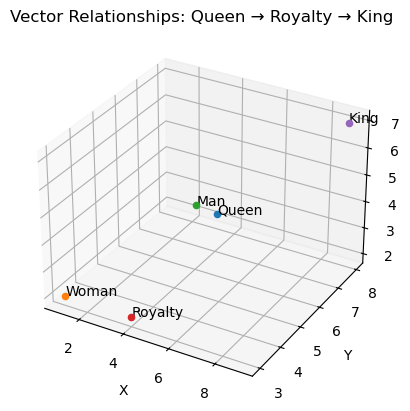

In [11]:
queen = np.array([5, 6, 4])
women = np.array([1, 3, 2])
man = np.array([5, 5, 5])
royalty = None
king = None
# im pretty sure I saw a video using this exact relationship
# to explain how LLMs work to me

royalty = queen - women
royalty

king = royalty + man
king

print(f"royalty:{royalty}")
print(f"king:{king}")

vectors = {
    "Queen": queen,
    "Woman": women,
    "Man": man,
    "Royalty": royalty,
    "King": king
}

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for label, vec in vectors.items():
    ax.scatter(vec[0], vec[1], vec[2])
    ax.text(vec[0], vec[1], vec[2], label)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Vector Relationships: Queen → Royalty → King")

plt.show()

## 2. Vector Magnitude
In class we learned the formula for vector magintude. 

Create your own implimentation of `vector_magnitude` not using `numpy.linalg.norm` but instead using vector operations in numpy. Use the test and example vectors to check your solution. 

In [13]:
def vector_magnitude(np_vector: npt.NDArray) -> np.float64:
    return np.sqrt(np.sum(np_vector ** 2))

def test_vector_magnitude(np_vector: npt.NDArray) -> None:
    if vector_magnitude(np_vector) == np.linalg.norm(np_vector):
        print(f"Test passed for {np_vector}")
    else:
        print(f"Test failed for {np_vector}")


d1_vector = np.array([5])
d2_vector = np.array([3.2, 0.1])
d3_vector = np.array([-2, 2, 2])
d10_vector = np.random.randint(100, size=(10))

test_vector_magnitude(d1_vector)
test_vector_magnitude(d2_vector)
test_vector_magnitude(d3_vector)
test_vector_magnitude(d10_vector)

Test passed for [5]
Test passed for [3.2 0.1]
Test passed for [-2  2  2]
Test passed for [37 32 72 33 42 51 86  1 96 88]


## 3. Unit Vectors
Using your implimentation of `vector_magnitude` above create a function `create_unit_vector` which creates a unit vector from a `np.array`. Create another function `test_create_unit_vector` following the pattern in `test_vector_magnitude` that tests the static vectors above with the corrisponding unit vectors defined below.

Hint: Use np.allclose instead of == . Explain why this is needed.

In [17]:
d1_unit_vector = np.array([1.])
d2_unit_vector = np.array([0.99951208, 0.03123475])
d3_unit_vector = np.array([-0.57735027,  0.57735027,  0.57735027])

#Impliment vector_magnitude and test_vector_magnitude here

def vector_magnitude(np_vector: npt.NDArray) -> np.float64:
    return np.sqrt(np.sum(np_vector ** 2))


def create_unit_vector(np_vector: npt.NDArray) -> npt.NDArray:
    magnitude = vector_magnitude(np_vector)
    return np_vector / magnitude

def test_create_unit_vector(np_vector: npt.NDArray, expected_unit_vector: npt.NDArray) -> None:
    unit_vector = create_unit_vector(np_vector)
    
    if np.allclose(unit_vector, expected_unit_vector):
        print(f"Test passed for {np_vector}")
    else:
        print(f"Test failed for {np_vector}")
        print(f"Expected: {expected_unit_vector}")
        print(f"Got:      {unit_vector}")

test_create_unit_vector(d1_vector, d1_unit_vector)
test_create_unit_vector(d2_vector, d2_unit_vector)
test_create_unit_vector(d3_vector, d3_unit_vector)

Test passed for [5]
Test passed for [3.2 0.1]
Test passed for [-2  2  2]


## 4. Dot Product
Again there exists a function in numpy that calculates the dot product formula we learrned in class, `numpy.dot`. For this problem you will write your on implimentation of the dot product using the formula from class and basic vector operations. You will alo need to create a test to compare your implimentation to `numpy.dot` and create 3 test cases that follow the guidance below.

1. The first test case should perform the dot product of a 3d vector with itself
2. The second test case should include integers and floats
3. For the third test case think of another edge case you might want to test against


In [ ]:
def dot_product(vec_a: npt.NDArray, vec_b: npt.NDArray) -> np.float64:
    return np.sum(vec_a * vec_b)

def test_dot_product(vec_a: npt.NDArray, vec_b: npt.NDArray) -> None:
    my_result = dot_product(vec_a, vec_b)
    np_result = np.dot(vec_a, vec_b)

    if np.allclose(my_result, np_result):
        print(f"Test passed for {vec_a} · {vec_b}")
    else:
        print(f"Test failed for {vec_a} · {vec_b}")
        print(f"Expected: {np_result}")
        print(f"Got:      {my_result}")

In [20]:
v1 = np.array([1, 2, 3])
test_dot_product(v1, v1)

Test passed for [1 2 3] · [1 2 3]


In [21]:
v2 = np.array([2, 3.5, -1])
v3 = np.array([4.0, -2, 0.5])
test_dot_product(v2, v3)


Test passed for [ 2.   3.5 -1. ] · [ 4.  -2.   0.5]


## 5. Predictions with dot products
Using linear regression we created the following model to predict the weight of a cat given the length and height. 

$$weight  = 0.23 * length + 1.07 * height + 3.412$$

Impliment a function `predict_weight` which will take in a 2d vector of a cat's length and height and will output the predicted weight of the cat. 

Also create a function `prediction_error` which will take the predicted weight and the actual weight of the cat and give the absolute value of the error between the two.

Use these functions to predict the weights of the cats below and figure out the error the predicted weights compared to the actual weights. Print out the results. 

In [22]:
def predict_weight(cat_vector: npt.NDArray) -> float:
    weights = np.array([0.23, 1.07])
    bias = 3.412
    return np.sum(weights * cat_vector) + bias

In [23]:
def prediction_error(predicted_weight: float, actual_weight: float) -> float:
    return abs(predicted_weight - actual_weight)

In [25]:
cat_1_array = np.array([28.57, 10.435])
cat_1_actual_weight = 24.21

cat_2_array = np.array([19.04, 6.93])
cat_2_actual_weight = 13.831

In [27]:
cat_1_pred = predict_weight(cat_1_array)
cat_1_err = prediction_error(cat_1_pred, cat_1_actual_weight)

cat_2_pred = predict_weight(cat_2_array)
cat_2_err = prediction_error(cat_2_pred, cat_2_actual_weight)

print(f"Cat 1 predicted weight: {cat_1_pred:.3f}")
print(f"Cat 1 prediction error: {cat_1_err:.3f}")

print(f"Cat 2 predicted weight: {cat_2_pred:.3f}")
print(f"Cat 2 prediction error: {cat_2_err:.3f}")


Cat 1 predicted weight: 21.149
Cat 1 prediction error: 3.061
Cat 2 predicted weight: 15.206
Cat 2 prediction error: 1.375


## 6. Linear Weighted Combinations
In class I showed the below code for calculating linear weighted combinations. 

```
l1 = 1
l2 = 2
l3 = -3
v1 = np.array([4,5,1])
v2 = np.array([-4,0,-4])
v3 = np.array([1,3,2])
l1*v1 + l2*v2 + l3*v3
```

Rewrite this code into a function called `linear_comb_loop` that will accept as input the scalars in a list and the vectors as elements in a list. Such that:

```
scalars_array = np.array([1, 2, -3])
vectors_array = np.array([[4,5,1], [-4,0,-4], [1,3,2]])

linear_comb_loop(scalars_array, vectors_array)
```

In this function use a for loop to implement the linear weighted combination operation. Initialize the output vector using np.zeros(). Confirm that you get the same result as in the previous code.

For 5 point extra credit create a second implementation that vectorizes this solution. Run some test that will check which implementation runs faster. These points will be added to your intial attempt and must be included in the intial attempt to recieve credit since you will likely get the solution in class.


In [29]:
import time

def linear_comb_loop(scalars: npt.NDArray, vectors: npt.NDArray) -> npt.NDArray:
    """
    Compute sum_i scalars[i] * vectors[i] using a for-loop.
    scalars: shape (m,)
    vectors: shape (m, d)
    returns: shape (d,)
    """
    out = np.zeros(vectors.shape[1], dtype=float)

    for i in range(len(scalars)):
        out += scalars[i] * vectors[i]

    return out

In [31]:
scalars_array = np.array([1, 2, -3])
vectors_array = np.array([[4, 5, 1],
                          [-4, 0, -4],
                          [1, 3, 2]])

print("Loop result:", linear_comb_loop(scalars_array, vectors_array))

# Original expression
l1, l2, l3 = scalars_array
v1, v2, v3 = vectors_array
print("Original result:", l1*v1 + l2*v2 + l3*v3)


Loop result: [ -7.  -4. -13.]
Original result: [ -7  -4 -13]


In [34]:
# Extra Credit
def linear_comb_vectorized(scalars: npt.NDArray, vectors: npt.NDArray) -> npt.NDArray:
    return np.sum(scalars[:, None] * vectors, axis=0)

def benchmark(func, scalars, vectors, repeats=2000):
    start = time.perf_counter()
    for _ in range(repeats):
        func(scalars, vectors)
    end = time.perf_counter()
    return end - start

# Make larger random test data so timing differences show up
m, d = 2000, 300
scalars_big = np.random.randn(m)
vectors_big = np.random.randn(m, d)

# Correctness checks
loop_ans = linear_comb_loop(scalars_big, vectors_big)
vec_ans  = linear_comb_vectorized(scalars_big, vectors_big)

print("loop vs vectorized allclose:", np.allclose(loop_ans, vec_ans))

# Timing
t_loop = benchmark(linear_comb_loop, scalars_big, vectors_big)
t_vec  = benchmark(linear_comb_vectorized, scalars_big, vectors_big)

print(f"Loop time:       {t_loop:.4f} seconds")
print(f"Vectorized time: {t_vec:.4f} seconds")


loop vs vectorized allclose: True
Loop time:       2.3531 seconds
Vectorized time: 0.8340 seconds


Clearly looks like vectorized is faster.

## 7. Create a Basis
In this exercise, you will draw random points in subspaces. This will help reinforce the idea that subspaces comprise any linear weighted combination of the spanning vectors. Define a vector set containing one vector [1, 3]. Then create 100 numbers drawn randomly from a uniform distribution between −4 and +4. Those are your random scalars. Multiply the random scalars by the basis vector to create 100 random points in the subspace. Plot those points using `plot_vectors`.

In [35]:
import matplotlib.pyplot as plt

def plot_vectors(vectors):
    plt.scatter(*zip(*vectors))
    plt.show()

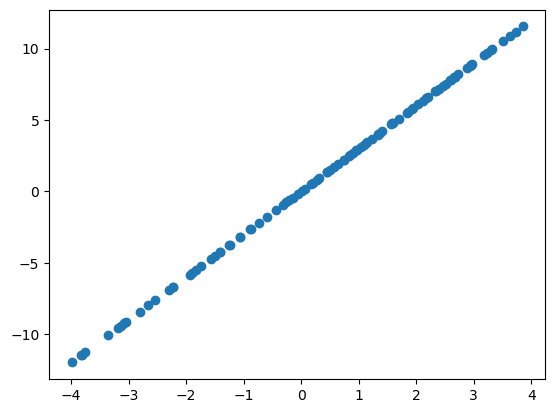

In [37]:
basis_vector = np.array([1, 3])
scalars = np.random.uniform(-4, 4, size=100)
points = scalars[:, None] * basis_vector
plot_vectors(points)

## 8. Extra Credit (10pts): Create a 3d Basis
This problem will not be graded on the final attempt and is only extra credit on the intial attempt and one of the problems a student can present in class for their participation credit that week.
These points will be added to your intial attempt and must be included in the intial attempt to recieve credit since you will likely get the solution in class.

Next, repeat the procedure but using two vectors in 3 dimensional space: [3, 5, 1] and [0, 2, 2]. Note that you need 100 × 2 random scalars for 100 points and two vectors. The resulting random dots will be on a plane. Plot this vectors on a 3 dimensional graph.


In [38]:
v1 = np.array([3, 5, 1])
v2 = np.array([0, 2, 2])

In [41]:
scalars = np.random.uniform(-4, 4, size=(100, 2))

points = scalars[:, 0, None] * v1 + scalars[:, 1, None] * v2

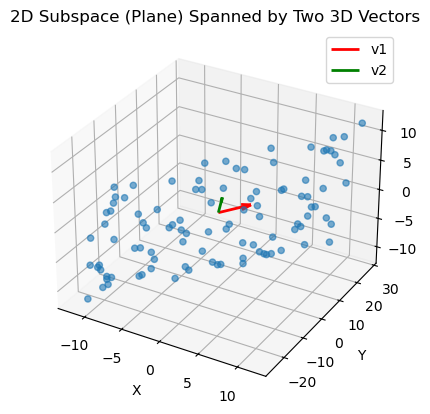

In [42]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the random points on the plane
ax.scatter(points[:, 0], points[:, 1], points[:, 2], alpha=0.6)

# Plot the basis vectors from the origin
ax.quiver(0, 0, 0, v1[0], v1[1], v1[2], color='r', linewidth=2, label='v1')
ax.quiver(0, 0, 0, v2[0], v2[1], v2[2], color='g', linewidth=2, label='v2')

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("2D Subspace (Plane) Spanned by Two 3D Vectors")
ax.legend()

plt.show()


## 9. Calculating Correlations 

Write two Python function that takes two vectors as input. The first one will calculate the Pearson correlation coefficient and the second cosine similarity value. Write code that follows the formulas presented in class; don’t simply call `np.corrcoef` and `spatial.distance.cosine`. 

Write the following tests:
1. `test_persons` which will test that your implimentation of the Pearson's correlation coefficient matches `np.corrcoef`.
2. `test_cosine` which will test that your implimentation of the cosine similarity value matches `spatial.distance.cosine`.
3. A test which will check if your implimentation of the Pearson's correlation coefficient matches your implimentation of the cosine similarity value. 


Create two test cases:
1. Mean centered vectors
2. Non-mean centered vectors

Run all three tests on the two test cases and describe what you find.

In [50]:
from scipy.spatial import distance
# I want to assume this is what it meant

In [44]:
def pearson(x: npt.NDArray, y: npt.NDArray) -> np.float64:
    # I'm implementing by what I found looking it up.
    # I think its on the slides too.
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.shape != y.shape:
        raise ValueError("x and y must have the same shape")

    x_centered = x - np.mean(x)
    y_centered = y - np.mean(y)

    num = np.sum(x_centered * y_centered)
    den = np.sqrt(np.sum(x_centered**2) * np.sum(y_centered**2))

    if den == 0:
        raise ValueError("Pearson correlation undefined when a vector has zero variance")

    return num / den


In [45]:
def cosine_similarity(x: npt.NDArray, y: npt.NDArray) -> np.float64:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.shape != y.shape:
        raise ValueError("x and y must have the same shape")

    num = np.sum(x * y)
    den = np.sqrt(np.sum(x**2) * np.sum(y**2))

    if den == 0:
        raise ValueError("Cosine similarity undefined when a vector has zero magnitude")

    return num / den

In [47]:
def cosine_distance(x: npt.NDArray, y: npt.NDArray) -> np.float64:
    return 1.0 - cosine_similarity(x, y)

In [53]:
def test_pearsons(x: npt.NDArray, y: npt.NDArray) -> None:
    my_r = pearson(x, y)
    np_r = np.corrcoef(x, y)[0, 1]

    if np.allclose(my_r, np_r):
        print("test_pearsons PASSED")
    else:
        print("test_perasons FAILED")
        print("mine:", my_r, "numpy:", np_r)

def test_cosine(x: npt.NDArray, y: npt.NDArray) -> None:
    my_d = cosine_distance(x, y)
    sp_d = distance.cosine(x, y)

    if np.allclose(my_d, sp_d):
        print("test_cosine PASSED")
    else:
        print("test_cosine FAILED")
        print("mine:", my_d, "scipy:", sp_d)

def test_pearson_equals_cosine(x: npt.NDArray, y: npt.NDArray) -> None:
    my_r = pearson(x, y)
    my_cos = cosine_similarity(x, y)

    if np.allclose(my_r, my_cos):
        print("test_pearson_equals_cosine PASSED")
    else:
        print("test_pearson_equals_cosine FAILED")
        print("pearson:", my_r, "cosine:", my_cos)

In [ ]:
# On to the actual test cases
x_raw = np.array([1, 2, 3, 4, 5], dtype=float)
y_raw = np.array([2, 1, 4, 3, 5], dtype=float)

x_centered = x_raw - np.mean(x_raw)
y_centered = y_raw - np.mean(y_raw)

x_noncenter = x_raw
y_noncenter = y_raw

print("=== Mean-centered case ===")
test_pearsons(x_centered, y_centered)
test_cosine(x_centered, y_centered)
test_pearson_equals_cosine(x_centered, y_centered)

print("\n=== Non-mean-centered case ===")
test_pearsons(x_noncenter, y_noncenter)
test_cosine(x_noncenter, y_noncenter)
test_pearson_equals_cosine(x_noncenter, y_noncenter)

# for mean centered cases, pearson correlation equals
# cosine similarity when vectors are mean-centered
# because its cosine sim on (x-x not) and (y-y not)

# on non mean centered cases, fails the equal
# cosine similarity measures angle from origin
# pearson recenters both vectors

=== Mean-centered case ===
test_pearsons PASSED
test_cosine PASSED
test_pearson_equals_cosine PASSED

=== Non-mean-centered case ===
test_pearsons PASSED
test_cosine PASSED
test_pearson_equals_cosine FAILED
pearson: 0.8 cosine: 0.9636363636363636
